# 第4章: 言語解析

問題30から問題35までは、以下の文章`text`（太宰治の『走れメロス』の冒頭部分）に対して、言語解析を実施せよ。問題36から問題39までは、国家を説明した文書群（日本語版ウィキペディア記事から抽出したテキスト群）をコーパスとして、言語解析を実施せよ。

In [ ]:
text = """
メロスは激怒した。
必ず、かの邪智暴虐の王を除かなければならぬと決意した。
メロスには政治がわからぬ。
メロスは、村の牧人である。
笛を吹き、羊と遊んで暮して来た。
けれども邪悪に対しては、人一倍に敏感であった。
"""

In [2]:
!pip install janome

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 64.6 MB/s eta 0:00:00


## 30. 動詞
文章`text`に含まれる動詞をすべて表示せよ。

In [ ]:
from janome.tokenizer import Tokenizer
t = Tokenizer()
for token in t.tokenize(text):
  if token.part_of_speech.split(',')[0] == '動詞':
    print(token.surface)

し
除か
なら
し
わから
吹き
遊ん
暮し
来


## 31. 動詞の原型
文章`text`に含まれる動詞と、その原型をすべて表示せよ。

In [ ]:
for token in t.tokenize(text):
  if token.part_of_speech.split(',')[0] == '動詞':
    print("動詞: ", token.surface, "\t", "原型: " ,token.base_form)

動詞:  し 	 原型:  する
動詞:  除か 	 原型:  除く
動詞:  なら 	 原型:  なる
動詞:  し 	 原型:  する
動詞:  わから 	 原型:  わかる
動詞:  吹き 	 原型:  吹く
動詞:  遊ん 	 原型:  遊ぶ
動詞:  暮し 	 原型:  暮す
動詞:  来 	 原型:  来る


## 32. 「AのB」
文章`text`において、2つの名詞が「の」で連結されている名詞句をすべて抽出せよ。

In [ ]:
takens = list(t.tokenize(text))
for i in range(len(takens)-2):
  t1 = takens[i]
  t2 = takens[i+1]
  t3 = takens[i+2]
  if (
      t1.part_of_speech.split(',')[0] == '名詞' and
      t2.surface == 'の' and
      t3.part_of_speech.split(',')[0] == '名詞'
  ):
    print(t1.surface + t2.surface + t3.surface)

暴虐の王
村の牧人


## 33. 係り受け解析

文章`text`に係り受け解析を適用し、係り元と係り先のトークン（形態素や文節などの単位）をタブ区切り形式ですべて抽出せよ。

In [ ]:
!pip install -U spacy==3.7.2
!pip install -U ginza ja_ginza

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.8 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.24.1
    Uninstalling typer-0.24.1:
      Successfully uninstalled typer-0.24.1
  Attempting uninstall: smart-open
    Found existing instal

ERROR: Operation cancelled by user
^C


In [ ]:
import spacy
import ginza
import ja_ginza

nlp = spacy.load("ja_ginza")

doc = nlp(text)

for sent in doc.sents:
    for token in sent:
        # token が係り元、token.head が係り先
        if token != token.head:
            print(token.text, "\t", token.head.text)


 	 メロス
メロス 	 激怒
は 	 メロス
し 	 激怒
た 	 激怒
。 	 激怒
必ず 	 除か
、 	 必ず
かの 	 暴虐
邪智 	 暴虐
暴虐 	 王
の 	 暴虐
王 	 除か
を 	 王
除か 	 決意
なけれ 	 除か
ば 	 なけれ
なら 	 なけれ
ぬ 	 なけれ
と 	 除か
し 	 決意
た 	 決意
。 	 決意

 	 メロス
メロス 	 わから
に 	 メロス
は 	 メロス
政治 	 わから
が 	 政治
ぬ 	 わから
。 	 わから

 	 メロス
メロス 	 牧人
は 	 メロス
、 	 メロス
村 	 牧人
の 	 村
で 	 牧人
ある 	 で
。 	 牧人

 	 笛
笛 	 吹き
を 	 笛
吹き 	 暮し
、 	 吹き
羊 	 遊ん
と 	 羊
遊ん 	 暮し
で 	 遊ん
て 	 暮し
来 	 て
た 	 暮し
。 	 暮し

 	 邪悪
けれど 	 

も 	 

邪悪 	 敏感
に 	 邪悪
対し 	 に
ては 	 に
、 	 邪悪
人 	 倍
一 	 倍
倍 	 敏感
に 	 倍
で 	 敏感
あっ 	 で
た 	 敏感
。 	 敏感


## 34. 主述の関係
文章`text`において、「メロス」が主語であるときの述語を抽出せよ。

In [ ]:
for sent in doc.sents:
    for token in sent:
        # 「メロス」が主語のとき
        if token.text == "メロス" and token.dep_ == "nsubj":
            predicate = token.head
            print(predicate.text)

激怒
牧人


## 35. 係り受け木
「メロスは激怒した。」の係り受け木を可視化せよ。

In [ ]:
import spacy
from spacy import displacy

nlp = spacy.load("ja_ginza")

doc = nlp("メロスは激怒した。")

displacy.render(doc, style="dep", jupyter=True)

## 36. 単語の出現頻度

問題36から39までは、Wikipediaの記事を以下のフォーマットで書き出したファイル[jawiki-country.json.gz](/data/jawiki-country.json.gz)をコーパスと見なし、統計的な分析を行う。

* 1行に1記事の情報がJSON形式で格納される
* 各行には記事名が"title"キーに、記事本文が"text"キーの辞書オブジェクトに格納され、そのオブジェクトがJSON形式で書き出される
* ファイル全体はgzipで圧縮される

まず、第3章の処理内容を参考に、Wikipedia記事からマークアップを除去し、各記事のテキストを抽出せよ。そして、コーパスにおける単語（形態素）の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [ ]:
import gzip, json, re
from collections import Counter
from janome.tokenizer import Tokenizer

t = Tokenizer()
counter = Counter()

# 日本語を含むかどうか
jp_pattern = re.compile(r"[一-龥ぁ-んァ-ヶ]")

with gzip.open("jawiki-country.json.gz", "rt", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        text = obj["text"]



        for token in t.tokenize(text):
            base = token.base_form
            pos = token.part_of_speech.split(",")[0]

            if pos not in ["名詞", "動詞", "形容詞"]:
                continue

            # 記号・数字・英字だけのものを除外
            if not jp_pattern.search(base):
                continue

            counter[base] += 1

for word, freq in counter.most_common(20):
    print(word, freq)

する 48174
年 30229
れる 18574
いる 17519
月 13705
日 10508
人 10135
国 9082
なる 7570
ある 5835
語 5803
的 5263
世界 4819
こと 4642
リンク 4414
日本 4343
大統領 4056
政府 3646
ため 3551
州 3440


## 37. 名詞の出現頻度
コーパスにおける名詞の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [ ]:
import gzip, json, re
from collections import Counter
from janome.tokenizer import Tokenizer

t = Tokenizer()
counter = Counter()

# 日本語を含むかどうか
jp_pattern = re.compile(r"[一-龥ぁ-んァ-ヶ]")

with gzip.open("jawiki-country.json.gz", "rt", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        text = obj["text"]

        for token in t.tokenize(text):
            base = token.base_form
            pos = token.part_of_speech.split(",")[0]

            if pos != "名詞":
                continue

            # 記号・数字・英字だけのものを除外
            if not jp_pattern.search(base):
                continue

            counter[base] += 1

for word, freq in counter.most_common(20):
    print(word, freq)

年 30229
月 13705
日 10508
人 10135
国 9082
語 5803
的 5263
世界 4819
こと 4642
リンク 4414
日本 4343
大統領 4056
政府 3646
ため 3551
州 3440
島 3359
共和 3351
者 3312
経済 3227
人口 2964


## 38. TF・IDF
日本に関する記事における名詞のTF・IDFスコアを求め、TF・IDFスコア上位20語とそのTF, IDF, TF・IDFを表示せよ。

In [5]:
import gzip, json, re, math
from collections import Counter, defaultdict
from janome.tokenizer import Tokenizer

t = Tokenizer()

jp_pattern = re.compile(r"[一-龥ぁ-んァ-ヶ]")

# 日本記事のTF
tf_counter = Counter()
total_terms = 0

# 文書頻度 DF
df = defaultdict(int)

N = 0  # 文書数

with gzip.open("jawiki-country.json.gz", "rt", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        text = obj["text"]
        title = obj["title"]

        nouns = []

        for token in t.tokenize(text):
            base = token.base_form
            if base == "*":
                base = token.surface

            pos = token.part_of_speech.split(",")[0]

            if pos != "名詞":
                continue

            if not jp_pattern.search(base):
                continue

            nouns.append(base)

        # 文書数カウント
        N += 1

        # DF（その文書に1回でも出たら+1）
        for word in set(nouns):
            df[word] += 1

        # 日本記事のTF
        if title == "日本":
            tf_counter = Counter(nouns)
            total_terms = len(nouns)


# TF-IDF計算
results = []

for word, tf in tf_counter.items():
    tf_norm = tf / total_terms
    idf = math.log(N / df[word]) + 1
    tfidf = tf_norm * idf
    results.append((word, tf_norm, idf, tfidf))


# 上位20語
results.sort(key=lambda x: x[3], reverse=True)

print("単語\tTF\t\tIDF\tTF-IDF")
for word, tf_norm, idf, tfidf in results[:20]:
    print(f"{word}\t{tf_norm:.6f}\t{idf:.4f}\t{tfidf:.6f}")

単語	TF		IDF	TF-IDF
日本	0.032694	1.1153	0.036462
年	0.029058	1.0081	0.029293
日	0.011610	1.0286	0.011942
月	0.011243	1.0204	0.011472
県	0.006372	1.5298	0.009748
国	0.009208	1.0122	0.009320
天皇	0.002569	3.6231	0.009307
琉球	0.001668	5.4148	0.009032
的	0.007706	1.0412	0.008024
倭	0.001535	5.1271	0.007868
倭国	0.001334	5.8203	0.007767
中国	0.004170	1.7012	0.007094
沖縄	0.001802	3.7408	0.006739
朝鮮	0.001835	3.6231	0.006648
世界	0.006038	1.0370	0.006262
人	0.006005	1.0204	0.006127
列島	0.001435	4.1155	0.005904
日本書紀	0.000901	6.5134	0.005867
こと	0.005471	1.0370	0.005673
韓国	0.002168	2.5816	0.005598


## 39. Zipfの法則
コーパスにおける単語の出現頻度順位を横軸、その出現頻度を縦軸として、両対数グラフをプロットせよ。

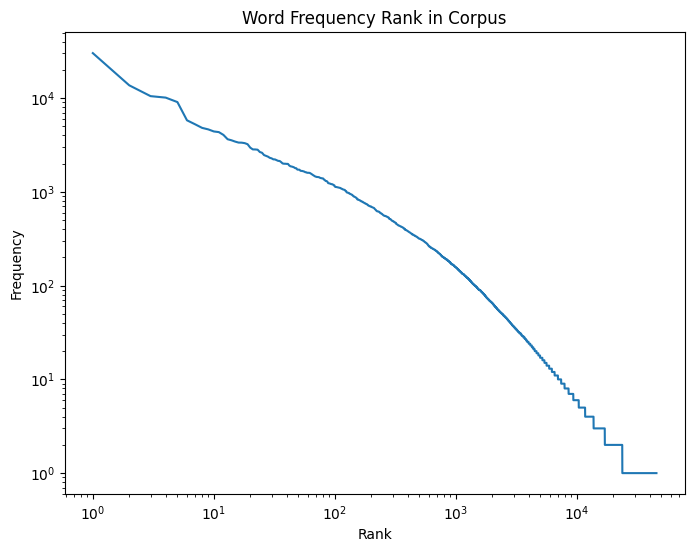

In [ ]:
import matplotlib.pyplot as plt

# 出現頻度の降順リスト
freqs = [freq for word, freq in counter.most_common()]

# 順位
ranks = range(1, len(freqs) + 1)

# 両対数グラフ
plt.figure(figsize=(8, 6))
plt.plot(ranks, freqs)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Word Frequency Rank in Corpus")

plt.show()